In [1]:
import os
import cv2
import matplotlib.pyplot as plt
import numpy as np
from skimage.metrics import mean_squared_error as mse
from skimage.metrics import structural_similarity as ssim

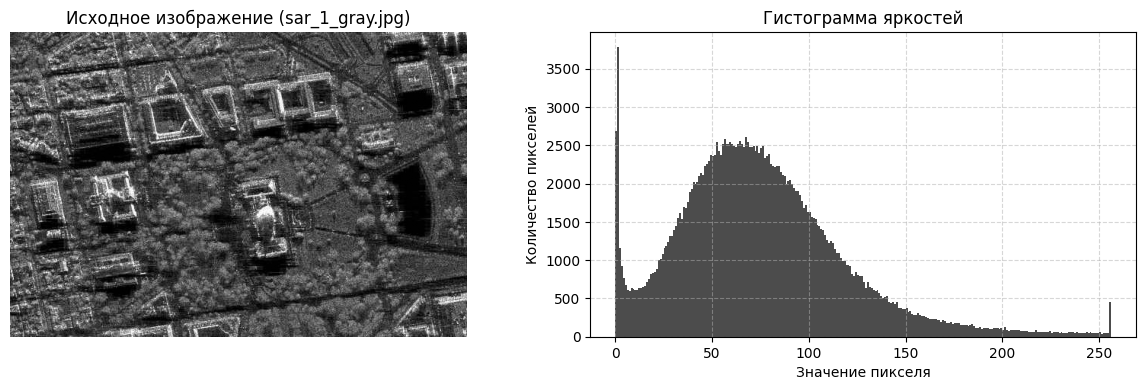

In [2]:
# Поиск файла в текущей папке или в /content/
img_path = (
    'sar_1_gray.jpg'
    if os.path.exists('sar_1_gray.jpg')
    else '/content/sar_1_gray.jpg'
)

# 1. Загрузка в оттенках серого
img_gray = cv2.imread(img_path, cv2.IMREAD_GRAYSCALE)

if img_gray is None:
  raise FileNotFoundError(
      f'Файл {img_path} не найден! Убедитесь, что загрузили sar_1_gray.jpg в'
      ' папку content.'
  )

# 2. Построение изображения и гистограммы
plt.figure(figsize=(12, 4))

plt.subplot(1, 2, 1)
plt.imshow(img_gray, cmap='gray')
plt.title('Исходное изображение (sar_1_gray.jpg)')
plt.axis('off')

plt.subplot(1, 2, 2)
plt.hist(img_gray.ravel(), bins=256, range=[0, 256], color='black', alpha=0.7)
plt.title('Гистограмма яркостей')
plt.xlabel('Значение пикселя')
plt.ylabel('Количество пикселей')
plt.grid(True, linestyle='--', alpha=0.5)

plt.tight_layout()
plt.show()

=== Результаты сравнения (Гамма-коррекция) ===
Гамма = 0.5 (< 1) : MSE = 2383.76, SSIM = 0.5270
Гамма = 2.0 (> 1) : MSE = 3250.43, SSIM = 0.7875



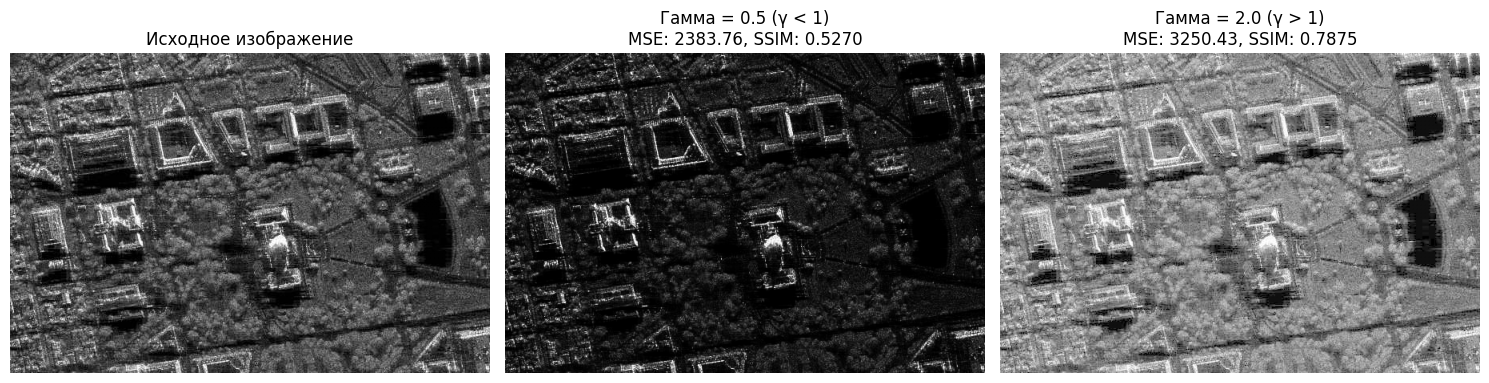

In [3]:
# 3. Реализация алгоритма гамма-коррекции
def gamma_correction(image, gamma):
  inv_gamma = 1.0 / gamma
  table = np.array([((i / 255.0) ** inv_gamma) * 255 for i in range(256)]).astype(
      'uint8'
  )
  return cv2.LUT(image, table)


gamma_low = 0.5  # гамма < 1
gamma_high = 2.0  # гамма > 1

img_gamma_low = gamma_correction(img_gray, gamma=gamma_low)
img_gamma_high = gamma_correction(img_gray, gamma=gamma_high)

# 4. Расчет MSE и SSIM
mse_low = mse(img_gray, img_gamma_low)
ssim_low = ssim(img_gray, img_gamma_low)

mse_high = mse(img_gray, img_gamma_high)
ssim_high = ssim(img_gray, img_gamma_high)

print('=== Результаты сравнения (Гамма-коррекция) ===')
print(f'Гамма = {gamma_low} (< 1) : MSE = {mse_low:.2f}, SSIM = {ssim_low:.4f}')
print(
    f'Гамма = {gamma_high} (> 1) : MSE = {mse_high:.2f}, SSIM = {ssim_high:.4f}\n'
)

# Вывод результатов
plt.figure(figsize=(15, 5))

plt.subplot(1, 3, 1)
plt.imshow(img_gray, cmap='gray')
plt.title('Исходное изображение')
plt.axis('off')

plt.subplot(1, 3, 2)
plt.imshow(img_gamma_low, cmap='gray')
plt.title(f'Гамма = {gamma_low} (γ < 1)\nMSE: {mse_low:.2f}, SSIM: {ssim_low:.4f}')
plt.axis('off')

plt.subplot(1, 3, 3)
plt.imshow(img_gamma_high, cmap='gray')
plt.title(
    f'Гамма = {gamma_high} (γ > 1)\nMSE: {mse_high:.2f}, SSIM: {ssim_high:.4f}'
)
plt.axis('off')

plt.tight_layout()
plt.show()

=== Статистика изображений ===
Исходное: mean = 74.94, std = 43.66
eq_gray : mean = 126.52, std = 74.26
Результат коррекции: mean = 122.65, std = 65.35



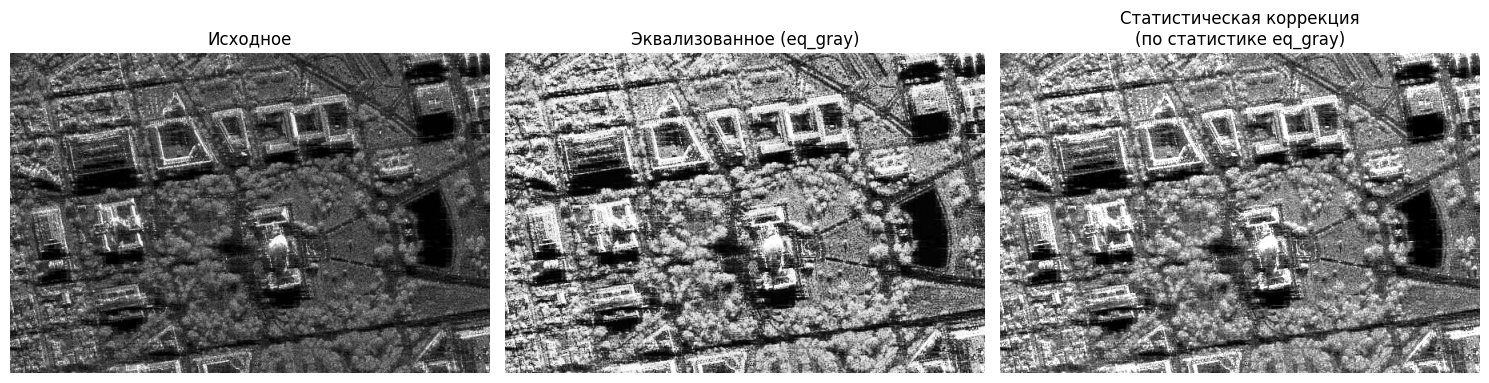

In [4]:
# 5.1. Собственная реализация эквализации гистограммы (из Notes.docx)
def custom_equalize_hist(image):
  hist, _ = np.histogram(image.flatten(), bins=256, range=[0, 256])
  cdf = hist.cumsum()
  cdf_m = np.ma.masked_equal(cdf, 0)
  cdf_m = (cdf_m - cdf_m.min()) * 255 / (cdf_m.max() - cdf_m.min())
  cdf_final = np.ma.filled(cdf_m, 0).astype('uint8')
  return cdf_final[image]


# Получаем эталон eq_gray
eq_gray = custom_equalize_hist(img_gray)


# 5.2. Алгоритм статистической коррекции на основе среднего и дисперсии целевого изображения (eq_gray)
def statistical_color_correction(src, target):
  src_f = src.astype(np.float64)
  target_f = target.astype(np.float64)

  src_mean, src_std = np.mean(src_f), np.std(src_f)
  tgt_mean, tgt_std = np.mean(target_f), np.std(target_f)

  # Сопоставление распределений: ((I - mean_src) * (std_tgt / std_src)) + mean_tgt
  corrected = (
      (src_f - src_mean) * (tgt_std / (src_std + 1e-6))
  ) + tgt_mean  # 1e-6 защита от нуля
  return np.clip(corrected, 0, 255).astype(np.uint8)


stat_corrected = statistical_color_correction(img_gray, eq_gray)

print('=== Статистика изображений ===')
print(f'Исходное: mean = {np.mean(img_gray):.2f}, std = {np.std(img_gray):.2f}')
print(f'eq_gray : mean = {np.mean(eq_gray):.2f}, std = {np.std(eq_gray):.2f}')
print(
    'Результат коррекции: mean ='
    f' {np.mean(stat_corrected):.2f}, std = {np.std(stat_corrected):.2f}\n'
)

# Вывод результатов
plt.figure(figsize=(15, 5))

plt.subplot(1, 3, 1)
plt.imshow(img_gray, cmap='gray')
plt.title('Исходное')
plt.axis('off')

plt.subplot(1, 3, 2)
plt.imshow(eq_gray, cmap='gray')
plt.title('Эквализованное (eq_gray)')
plt.axis('off')

plt.subplot(1, 3, 3)
plt.imshow(stat_corrected, cmap='gray')
plt.title('Статистическая коррекция\n(по статистике eq_gray)')
plt.axis('off')

plt.tight_layout()
plt.show()

=== Пороговая фильтрация ===
Вычисленный оптимальный порог Оцу: 85.00



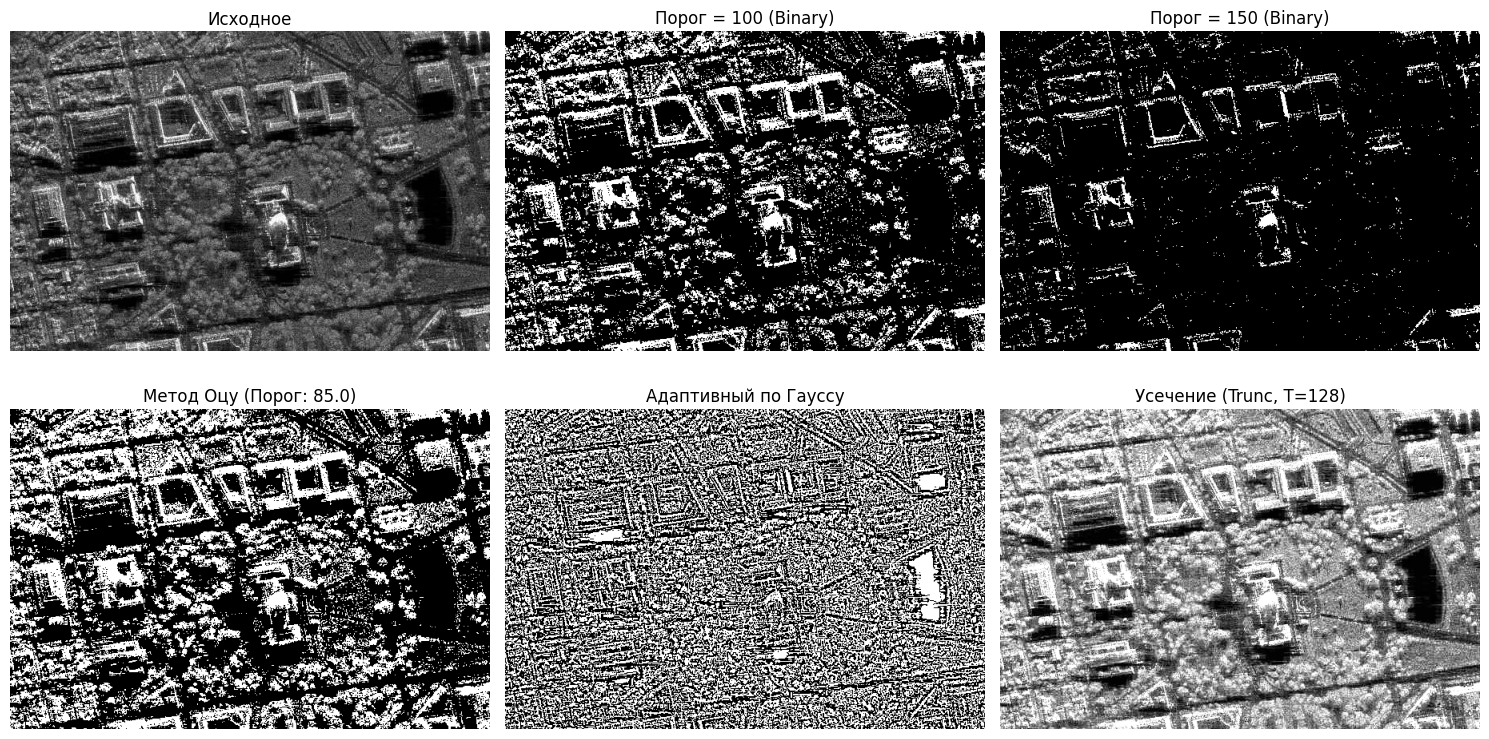

In [5]:
# 6. Алгоритмы пороговой фильтрации с различными параметрами

# 1) Бинаризация с фиксированным порогом 100
_, th_simple_100 = cv2.threshold(img_gray, 100, 255, cv2.THRESH_BINARY)

# 2) Бинаризация с фиксированным порогом 150
_, th_simple_150 = cv2.threshold(img_gray, 150, 255, cv2.THRESH_BINARY)

# 3) Бинаризация методом Оцу (автоматический расчет глобального порога)
val_otsu, th_otsu = cv2.threshold(
    img_gray, 0, 255, cv2.THRESH_BINARY + cv2.THRESH_OTSU
)

# 4) Адаптивная пороговая фильтрация (локальное окно по Гауссу)
th_adaptive = cv2.adaptiveThreshold(
    img_gray, 255, cv2.ADAPTIVE_THRESH_GAUSSIAN_C, cv2.THRESH_BINARY, 11, 2
)

# 5) Пороговое усечение (THRESH_TRUNC) с порогом 128
_, th_trunc = cv2.threshold(img_gray, 128, 255, cv2.THRESH_TRUNC)

print('=== Пороговая фильтрация ===')
print(f'Вычисленный оптимальный порог Оцу: {val_otsu:.2f}\n')

titles = [
    'Исходное',
    'Порог = 100 (Binary)',
    'Порог = 150 (Binary)',
    f'Метод Оцу (Порог: {val_otsu:.1f})',
    'Адаптивный по Гауссу',
    'Усечение (Trunc, T=128)',
]

images = [
    img_gray,
    th_simple_100,
    th_simple_150,
    th_otsu,
    th_adaptive,
    th_trunc,
]

plt.figure(figsize=(15, 8))
for i in range(6):
  plt.subplot(2, 3, i + 1)
  plt.imshow(images[i], cmap='gray')
  plt.title(titles[i])
  plt.axis('off')

plt.tight_layout()
plt.show()